In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Dataset Description**

Salary Dataset in CSV for Simple linear regression.

Columns

YearsExperience

Salary

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [3]:
file_path = "/content/drive/MyDrive/2025_2026/PSM/Regression_1/Datasets/Salary_dataset.csv"

df = pd.read_csv(file_path)

In [4]:
print(df.head(10))
print(df.info())
print(df.describe())

   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
5           5              3.0  56643.0
6           6              3.1  60151.0
7           7              3.3  54446.0
8           8              3.3  64446.0
9           9              3.8  57190.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None
       Unnamed: 0  YearsExperience         Salary
count   30.000000        30.000000      30.000000
mean    14.500000         5.413333   76004.000000
std      8.803408 

In [5]:
# Select features
X = df["YearsExperience"].values.reshape(-1, 1)
y = df["Salary"].values

Data visualization

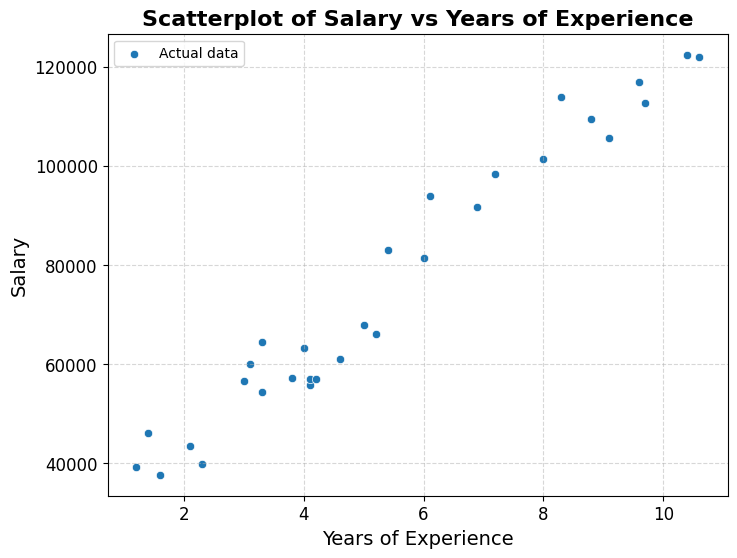

In [6]:
# Scatterplot visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["YearsExperience"], y=df["Salary"], label="Actual data")
plt.xlabel("Years of Experience", fontsize=14)
plt.ylabel("Salary", fontsize=14)
plt.title("Scatterplot of Salary vs Years of Experience", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency


plt.show()

In [7]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Linear Regression Model

In [8]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)


 Evaluate linear model

In [9]:
mse_lin = mean_squared_error(y_test, y_pred)
rmse_lin = np.sqrt(mse_lin)
mae_lin = mean_absolute_error(y_test, y_pred)
r2_lin = r2_score(y_test, y_pred)

print(f"Linear Regression MSE: {np.round(mse_lin,3)}, RMSE: {np.round(rmse_lin,3)}, MAE: {np.round(mae_lin,3)}, R2: {np.round(r2_lin,3)}")

Linear Regression MSE: 37784662.466, RMSE: 6146.923, MAE: 5161.329, R2: 0.941


Plotting

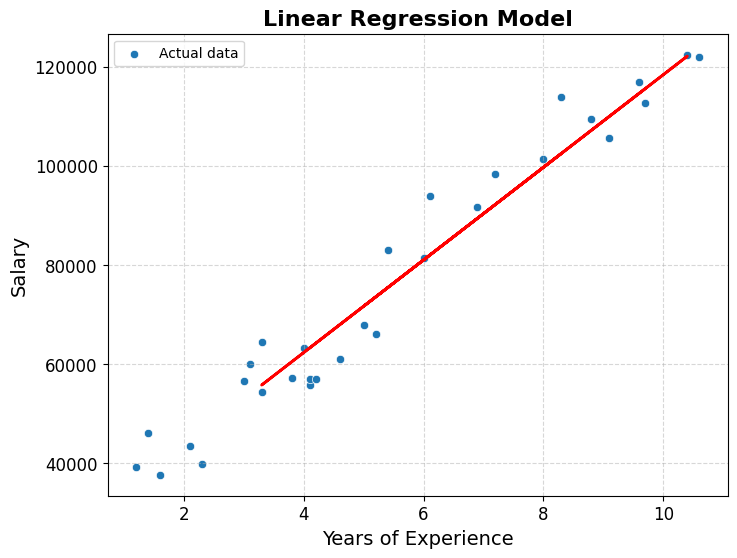

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["YearsExperience"], y=df["Salary"], label="Actual data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Linear Regression")
plt.xlabel("Years of Experience", fontsize=14)
plt.ylabel("Salary", fontsize=14)
plt.title("Linear Regression Model", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency


plt.show()

Statistics

In [11]:
# Statistical evaluation of the linear model
X_train_const = sm.add_constant(X_train)
model_lin = sm.OLS(y_train, X_train_const).fit()
summary_lin = model_lin.summary()
print(summary_lin)

print("Coefficients (Linear Regression):", lin_reg.coef_)
print("Intercept (Linear Regression):", lin_reg.intercept_)



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     427.6
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           1.74e-14
Time:                        12:41:08   Log-Likelihood:                -210.19
No. Observations:                  21   AIC:                             424.4
Df Residuals:                      19   BIC:                             426.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.499e+04   2546.938      9.810      0.0

Polynomial regression model

In [12]:
degrees = [2, 3, 4, 5]
errors = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    poly_reg = LinearRegression()
    poly_reg.fit(X_poly_train, y_train)

    y_poly_pred = poly_reg.predict(X_poly_test)
    mse_poly = mean_squared_error(y_test, y_poly_pred)
    errors.append(mse_poly)

optimal_degree = degrees[np.argmin(errors)]

print(f"Optimal degree for polynomial regression: {optimal_degree}")

poly = PolynomialFeatures(degree=optimal_degree)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train)
y_poly_pred = poly_reg.predict(X_poly_test)

Optimal degree for polynomial regression: 5


Evaluate polynomial model

In [13]:
mse_poly = mean_squared_error(y_test, y_poly_pred)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_poly_pred)
r2_poly = r2_score(y_test, y_poly_pred)

print(f"Polynomial Regression MSE: {np.round(mse_poly,3)}, RMSE: {np.round(rmse_poly,3)}, MAE: {np.round(mae_poly,3)}, R2: {np.round(r2_poly,3)}")

Polynomial Regression MSE: 32315728.753, RMSE: 5684.692, MAE: 4183.071, R2: 0.95


Plotting

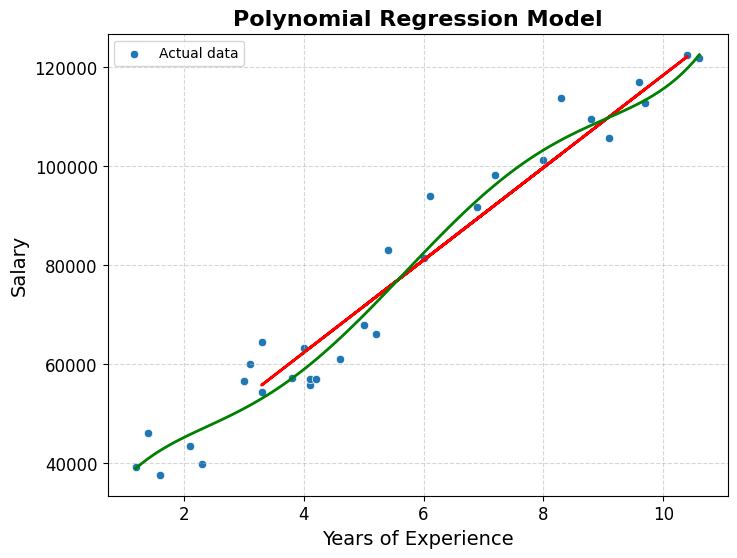

In [14]:
X_grid = np.linspace(min(X), max(X), 100).reshape(-1, 1)
X_poly_grid = poly.transform(X_grid)
y_poly_grid = poly_reg.predict(X_poly_grid)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["YearsExperience"], y=df["Salary"], label="Actual data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Linear Regression")
plt.plot(X_grid, y_poly_grid, color="green", linewidth=2, label=f"Polynomial Regression (degree={optimal_degree})")
plt.xlabel("Years of Experience", fontsize=14)
plt.ylabel("Salary", fontsize=14)
plt.title("Polynomial Regression Model", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency


plt.show()

Statistics

In [15]:

X_poly_train_const = sm.add_constant(X_poly_train)
model_poly = sm.OLS(y_train, X_poly_train_const).fit()
summary_poly = model_poly.summary()
print(summary_poly)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     88.18
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           1.41e-10
Time:                        12:43:51   Log-Likelihood:                -207.49
No. Observations:                  21   AIC:                             427.0
Df Residuals:                      15   BIC:                             433.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.536e+04   3.26e+04      0.470      0.6

Regression model on synthetic data

In [16]:
def generate_poly_data(n_samples=300,
                       degree=3,
                       noise_var=1.0,
                       x_min=-3,
                       x_max=3,
                       seed=42):
    np.random.seed(seed)

    # 1. Generate input feature values (deterministic grid)
    x = np.linspace(x_min, x_max, n_samples)

    # 2. Default polynomial coefficients
    # a0 = 1, a1 = -2, higher-order terms decrease in magnitude
    coef = np.zeros(degree + 1)
    coef[0] = 1
    if degree >= 2:
        coef[1] = -2
    for k in range(2, degree + 1):
        coef[k] = (-1)**k / (k + 1)

    # 3. Compute the noiseless polynomial signal
    y_true = np.zeros(n_samples)
    for k in range(degree + 1):
        y_true += coef[k] * x**k

    # 4. Add Gaussian noise with variance = noise_var
    noise = np.random.normal(0, np.sqrt(noise_var), n_samples)
    y = y_true + noise

     # Create DataFrame
    df = pd.DataFrame({
        "X": x,
        "Y": y
    })

    return df

In [17]:
df = generate_poly_data(degree=4, noise_var=2)

print(df.head(10))

          X          Y
0 -3.000000  33.652460
1 -2.979933  32.110669
2 -2.959866  32.589028
3 -2.939799  33.204325
4 -2.919732  30.107067
5 -2.899666  29.505135
6 -2.879599  31.477789
7 -2.859532  29.747973
8 -2.839465  27.426830
9 -2.819398  28.295949


In [ ]:
file_path = "/content/drive/MyDrive/2025_2026/PSM/Regression_1/Datasets/Synthetic_dataset.csv"

df.to_csv(file_path, index=False)

In [18]:
# Select features
X = df["X"].values.reshape(-1, 1)
y = df["Y"].values

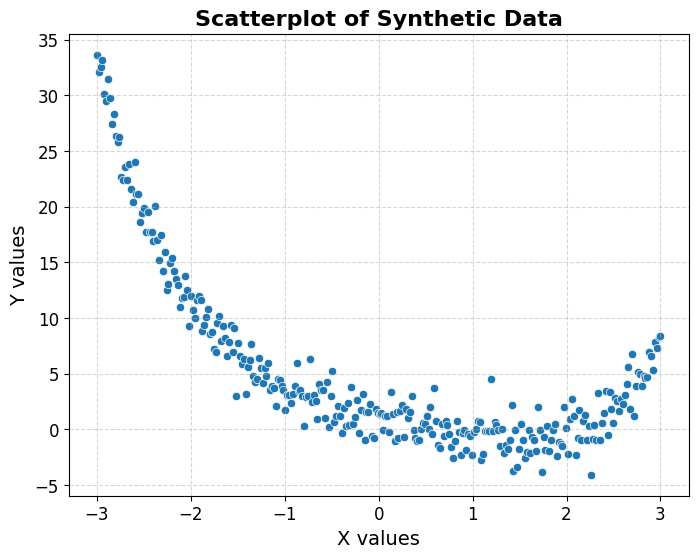

In [19]:
# Scatterplot visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="X", y="Y")
plt.xlabel("X values", fontsize=14)
plt.ylabel("Y values", fontsize=14)
plt.title("Scatterplot of Synthetic Data", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency


plt.show()

In [20]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [21]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

mse_lin = mean_squared_error(y_test, y_pred)
rmse_lin = np.sqrt(mse_lin)
mae_lin = mean_absolute_error(y_test, y_pred)
r2_lin = r2_score(y_test, y_pred)

print(f"Linear Regression MSE: {np.round(mse_lin,3)}, RMSE: {np.round(rmse_lin,3)}, MAE: {np.round(mae_lin,3)}, R2: {np.round(r2_lin,3)}")

Linear Regression MSE: 31.889, RMSE: 5.647, MAE: 4.428, R2: 0.529


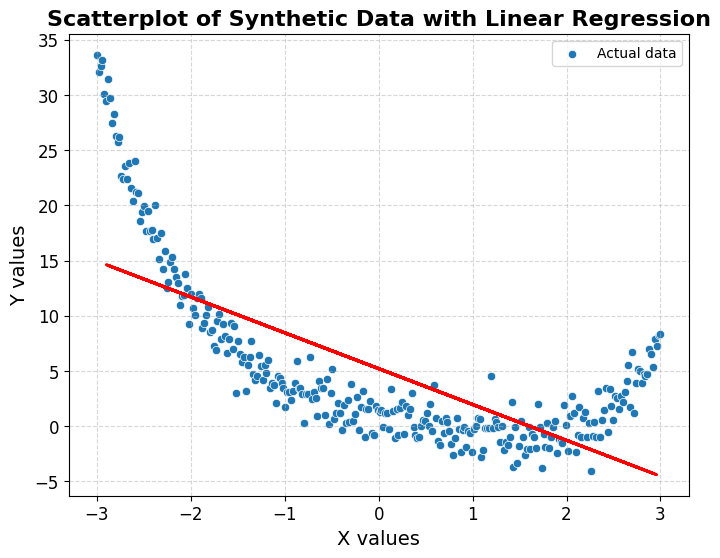

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["X"], y=df["Y"], label="Actual data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Linear Regression")
plt.xlabel("X values", fontsize=14)
plt.ylabel("Y values", fontsize=14)
plt.title("Scatterplot of Synthetic Data with Linear Regression", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency


plt.show()

In [23]:
degrees = [2, 3, 4, 5, 6, 7, 8, 9, 10]
errors = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    poly_reg = LinearRegression()
    poly_reg.fit(X_poly_train, y_train)

    y_poly_pred = poly_reg.predict(X_poly_test)
    mse_poly = mean_squared_error(y_test, y_poly_pred)
    errors.append(mse_poly)

optimal_degree = degrees[np.argmin(errors)]

print(f"Optimal degree for polynomial regression: {optimal_degree}")

poly = PolynomialFeatures(degree=optimal_degree)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train)
y_poly_pred = poly_reg.predict(X_poly_test)

Optimal degree for polynomial regression: 4


In [24]:
mse_poly = mean_squared_error(y_test, y_poly_pred)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_poly_pred)
r2_poly = r2_score(y_test, y_poly_pred)

print(f"Polynomial Regression MSE: {np.round(mse_poly,3)}, RMSE: {np.round(rmse_poly,3)}, MAE: {np.round(mae_poly,3)}, R2: {np.round(r2_poly,3)}")

Polynomial Regression MSE: 1.422, RMSE: 1.192, MAE: 0.933, R2: 0.979


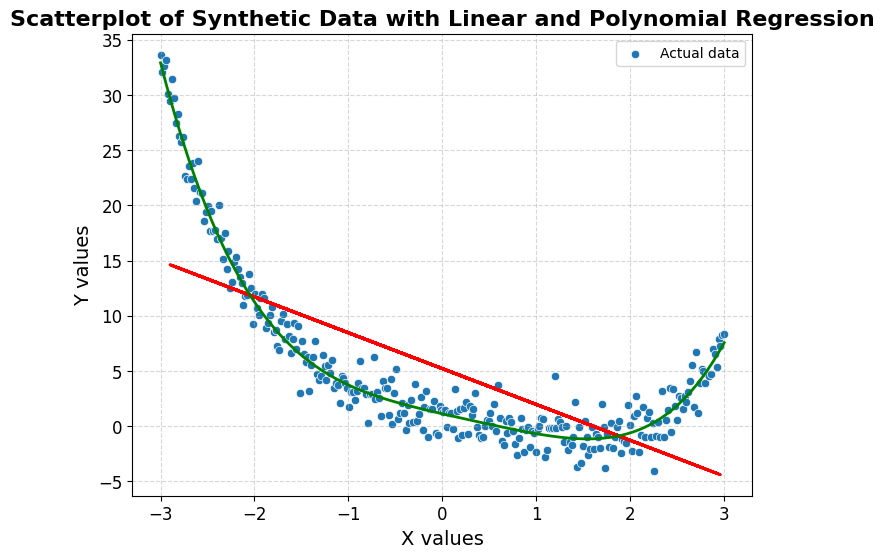

In [25]:
X_grid = np.linspace(min(X), max(X), 100).reshape(-1, 1)
X_poly_grid = poly.transform(X_grid)
y_poly_grid = poly_reg.predict(X_poly_grid)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["X"], y=df["Y"], label="Actual data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Linear Regression")
plt.plot(X_grid, y_poly_grid, color="green", linewidth=2, label=f"Polynomial Regression (degree={optimal_degree})")
plt.xlabel("X values", fontsize=14)
plt.ylabel("Y values", fontsize=14)
plt.title("Scatterplot of Synthetic Data with Linear and Polynomial Regression", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency


plt.show()

Nonlinear regression models

In [26]:
file_path = "/content/drive/MyDrive/2025_2026/PSM/Regression_1/Datasets/L_minor.txt"

L_minor = pd.read_csv(file_path, delimiter=' ', quotechar='"')
print(L_minor)

         conc        rate
1    2.856829   14.583419
2    5.005303   24.741225
3    7.519473   31.345506
4   22.101664   72.969855
5   27.769976   77.500987
6   39.198025   96.087941
7   45.483269   96.966236
8  203.784238  108.883735


In [27]:
X = L_minor["conc"].values
y = L_minor["rate"].values
X = X.reshape(-1, 1)

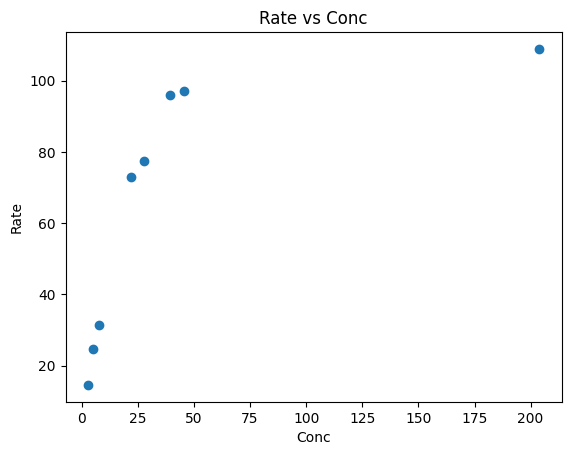

In [28]:
plt.scatter(X, y)
plt.xlabel('Conc')
plt.ylabel('Rate')
plt.title('Rate vs Conc')
plt.show()

In [29]:
def model_func(conc, a, b):
    return (a * conc) / (1 + b * conc)

In [30]:
from scipy.optimize import curve_fit

In [31]:
conc = np.array(X)
rate = np.array(y)
conc = conc.flatten()
print(conc)
print(rate)

[  2.8568294    5.00530261   7.5194734   22.10166392  27.76997623
  39.19802523  45.48326934 203.7842384 ]
[ 14.583419    24.741225    31.34550584  72.96985478  77.50098731
  96.08794121  96.96623608 108.8837353 ]


In [32]:
# Initial guess for the parameters
initial_guess = [1, 1]

# Perform the curve fitting
param_opt, param_cov = curve_fit(model_func, conc, rate, p0=initial_guess)

# Extract the optimized parameter values
a_opt, b_opt = param_opt
print(f"Optimized parameters: a = {a_opt}, b = {b_opt}")

Optimized parameters: a = 7.379367506214158, b = 0.058551082606416345


In [34]:
# Predicting using the optimized parameters
rate_pred = model_func(conc, *param_opt)

# Calculate residuals
residuals_nonlinear_1 = rate - rate_pred

mse_nonlinear = mean_squared_error(rate, rate_pred)
rmse_nonlinear = np.sqrt(mse_nonlinear)
r2_nonlinear = r2_score(rate, rate_pred)

print(f"Nonlinear Regression MSE: {mse_nonlinear}, RMSE: {rmse_nonlinear}, R2: {r2_nonlinear}")

Nonlinear Regression MSE: 29.294137494739523, RMSE: 5.412405887841333, R2: 0.9751426414238008


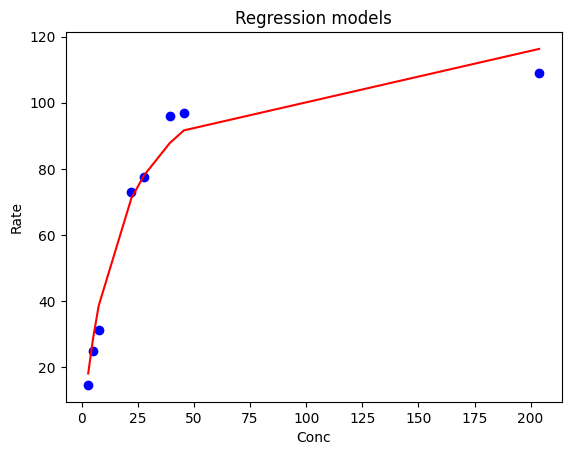

In [35]:
plt.scatter(X, y, color = 'blue')
plt.plot(X, rate_pred, color = 'red')
plt.title('Regression models')
plt.xlabel('Conc')
plt.ylabel('Rate')
plt.show()

The use of asymptotic 2 function

In [36]:
def nonlinear_model(x, a, b):
    return a * (1 - np.exp(-b * x))

In [37]:
# Initial guess for the parameters a and b
initial_guess = [1, 0.1]

# Fit the model
params_opt, params_cov = curve_fit(nonlinear_model, conc, rate, p0=initial_guess)

a_opt, b_opt = params_opt
print(f"Optimized parameters: a = {a_opt}, b = {b_opt}")

Optimized parameters: a = 109.54646180571336, b = 0.04809004671975365


/tmp/ipython-input-3494288847.py:2: RuntimeWarning: overflow encountered in exp
  return a * (1 - np.exp(-b * x))


In [38]:
# Generate model predictions
rate_pred_1 = nonlinear_model(conc, a_opt, b_opt)

residuals_nonlinear_2 = rate - rate_pred

# Calculate MSE and RMSE
mse = mean_squared_error(rate, rate_pred_1)
rmse = np.sqrt(mse)

# Calculate R-squared
r2 = r2_score(rate, rate_pred_1)

print(f"MSE: {mse}, RMSE: {rmse}, R^2: {r2}")

MSE: 3.525059951638444, RMSE: 1.8775143013139592, R^2: 0.9970088322540231


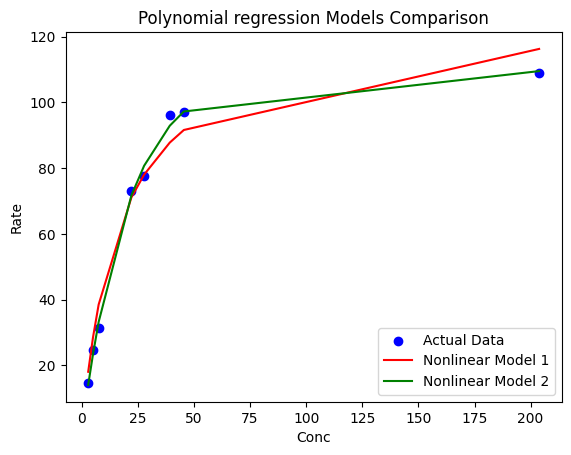

In [39]:
plt.scatter(conc, rate, color='blue', label='Actual Data')
plt.plot(conc, rate_pred, color='red', label='Nonlinear Model 1')
plt.plot(conc, rate_pred_1, color='green', label='Nonlinear Model 2')
plt.title('Polynomial regression Models Comparison')
plt.xlabel('Conc')
plt.ylabel('Rate')
plt.legend()
plt.show()